## Loading the results

RESCO writes one JSON file per run, with per-episode metrics keyed by a run hash.

This analysis uses six typed runs (Cologne1 and Ingolstadt1, all three 
algorithms), all trained through `run_typed_training.py`, which applies 
`dynamic_vlen_traffic_signal.py` before training starts. That patch corrects 
a real issue in RESCO itself -- it hardcodes every vehicle's length as 5m 
regardless of actual type, which caused Max-Pressure to behave catastrophically 
on Cologne1 once trucks were part of the traffic mix. The fix is a monkey-patch, 
not an edit to RESCO's own code (see dynamic_vlen_traffic_signal.py for why 
that approach was used), so RESCO's original files stay untouched.

In [28]:
# imports + path to where RESCO saved the results

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../RESCO/results"

In [29]:
# pulls scenario and algorithm out of a result filename
# e.g. cologne1typed+idqn_libsumo@... -> ("cologne1", "idqn")

def parse_run_name(filename):
    name = filename.replace(".json", "")
    scenario, rest = name.split("typed+")
    algorithm, _ = rest.split("_libsumo")
    return scenario, algorithm

print(parse_run_name('cologne1typed+idqn_libsumo@False_gui@False_f7d3ebe8c2102f8b.json'))

('cologne1', 'idqn')


In [30]:
# reads one run's JSON into a list of per-episode rows

def load_run(filepath):
    scenario, algorithm = parse_run_name(os.path.basename(filepath))
    with open(filepath) as f:
        data = json.load(f)

    run_hash = list(data["rewards"].keys())[0]
    n_episodes = len(data["rewards"][run_hash])

    rows = []
    for ep in range(n_episodes):
        row = {"scenario": scenario, "algorithm": algorithm, "episode": ep + 1}
        for metric in data:
            row[metric] = data[metric][run_hash][ep]
        rows.append(row)
    return rows

rows = load_run(os.path.join(RESULTS_DIR, "cologne1typed+idqn_libsumo@False_gui@False_d54ffcc727ee4d07.json"))
print('episodes loaded:', len(rows))
print('first row:', rows[0])
print('last row:', rows[-1])

episodes loaded: 99
first row: {'scenario': 'cologne1', 'algorithm': 'idqn', 'episode': 1, 'timeLoss': 438.61220843672464, 'duration': 220.52803970223326, 'waitingTime': 126.9047146401985, 'rewards': -12653.891816920943, 'max_queues': 25.649098474341194, 'queue_lengths': 89.34257975034674, 'vehicles': 2015.0, 'phase_length': 5.667128987517337}
last row: {'scenario': 'cologne1', 'algorithm': 'idqn', 'episode': 99, 'timeLoss': 34.38489330024815, 'duration': 55.44714640198511, 'waitingTime': 19.43424317617866, 'rewards': -567.1830790568655, 'max_queues': 5.174757281553398, 'queue_lengths': 13.894590846047157, 'vehicles': 2015.0, 'phase_length': 15.320388349514563}


In [31]:
# load every typed run in the results folder into one table

all_rows = []
for filename in os.listdir(RESULTS_DIR):
    if filename.endswith(".json") and "typed+" in filename:
        all_rows.extend(load_run(os.path.join(RESULTS_DIR, filename)))

results = pd.DataFrame(all_rows)
results.head()

,scenario,algorithm,episode,timeLoss,duration,waitingTime,rewards,max_queues,queue_lengths,vehicles,phase_length
0,cologne1,fixed,1,59.160402,76.752854,38.625310,-1029.841886,9.789182,25.800277,2015.0,15.993065
1,cologne1,fixed,2,57.366467,74.980645,37.268983,-972.922330,9.398058,24.324549,2015.0,16.034674
2,cologne1,fixed,3,54.854958,72.937469,34.946402,-858.746186,9.081831,23.177531,2015.0,15.993065
3,cologne1,fixed,4,58.287529,74.900744,36.671960,-966.563107,9.644938,24.807212,2015.0,16.034674
4,cologne1,fixed,5,59.036149,75.913648,37.631266,-949.497920,9.643551,25.395284,2015.0,15.993065


Now I have one DataFrame (`results`) with one row per episode per run — 
99 or 100 rows for each of the six scenario/algorithm combinations. 
Everything from here works off this table.

## Smoothing and plotting learning curves

Raw per-episode reward is noisy, since each episode draws different random 
traffic demand. I smooth with a rolling average to see the actual trend, 
then plot each algorithm's curve per city.

In [32]:
# smooth reward per (scenario, algorithm) so single noisy episodes don't dominate the trend

results = results.sort_values(["scenario", "algorithm", "episode"])
results["reward_smoothed"] = (
    results.groupby(["scenario", "algorithm"])["rewards"]
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

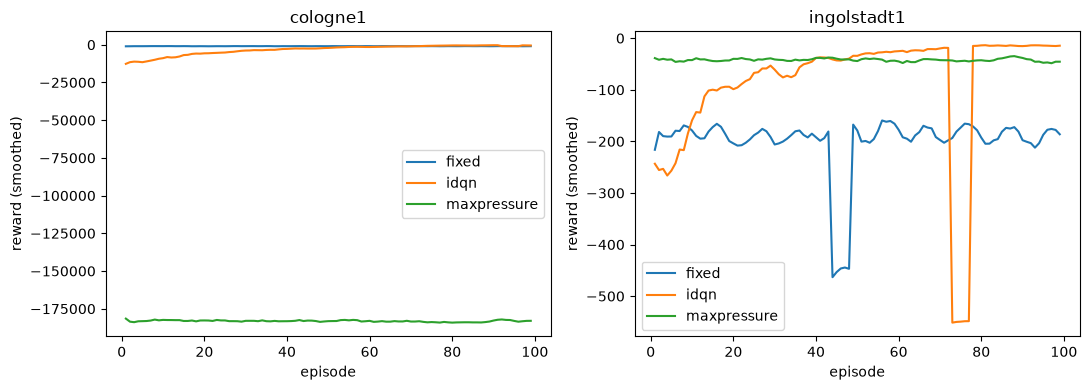

In [33]:
# one subplot per city, one line per algorithm

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, scenario in zip(axes, ["cologne1", "ingolstadt1"]):
    subset = results[results["scenario"] == scenario]
    for algorithm, alg_data in subset.groupby("algorithm"):
        ax.plot(alg_data["episode"], alg_data["reward_smoothed"], label=algorithm)
    ax.set_title(scenario)
    ax.set_xlabel("episode")
    ax.set_ylabel("reward (smoothed)")
    ax.legend()
plt.tight_layout()

In [34]:
# average reward over the last 20 episodes of each run = "converged" performance

converged = (
    results[results["episode"] > 80]
    .groupby(["scenario", "algorithm"])["rewards"]
    .mean()
)
print(converged)

scenario     algorithm  
cologne1     fixed            -952.245419
             idqn             -575.392072
             maxpressure   -183186.687130
ingolstadt1  fixed            -188.525586
             idqn              -14.555442
             maxpressure       -42.039273
Name: rewards, dtype: float64


### Results

Converged performance (average reward over the last 20 episodes), using the 
corrected vehicle-length model (dynamic_vlen_traffic_signal.py):

| | Fixed-Time | IDQN | Max-Pressure |
|---|---|---|---|
| Cologne1 | -952.25 | -575.39 | -183,186.69 |
| Ingolstadt1 | -188.53 | -14.56 | -42.04 |

**IDQN clearly outperforms Fixed-Time on both networks** -- about 40% less 
penalty on Cologne1, and roughly 13x less on Ingolstadt1. Comparing against 
the pre-patch run: Ingolstadt1's numbers are highly stable across both 
independent (unseeded) runs, which is reassuring. Cologne1's IDQN result 
shows more run-to-run movement (-478.94 before, -575.39 now) -- still a 
clear win over Fixed-Time either way, but a reminder that a single run per 
algorithm isn't a substitute for the multi-seed comparison the actual 
ablation will need.

**Max-Pressure on Cologne1 is still catastrophic: -183,186.69, essentially 
unchanged from before the vehicle-length fix (-183,133.34).** The correction 
was still worth making -- it fixes a real, acknowledged limitation in RESCO 
itself -- but this confirms it was not the actual root cause of this specific 
failure. The underlying mechanism (the signal freezing on one phase for 
almost the entire episode, found earlier) remains unexplained. This needs a 
decision before it goes anywhere near the thesis: either investigate further, 
or explicitly document Cologne1 Max-Pressure as an excluded/flagged data 
point rather than a valid comparison.

The dip visible in Ingolstadt1's IDQN curve (and the smaller one in 
Fixed-Time) is normal run-to-run training variance, not a concern -- RESCO 
doesn't support seeding, so exact episode-level shape differs between runs 
even where the converged outcome is consistent.

## Investigating the Cologne1 Max-Pressure anomaly

Max-Pressure on Cologne1's typed data converges to a reward roughly 190x worse 
than Fixed-Time on the same network (-183,186.69 vs -952.25) -- while Ingolstadt1 
shows no such issue for any algorithm. Two things have already been ruled out:

- **Hypothesis: Not a random fluke**: repeated runs with different (unseeded) demand all 
  land in the same catastrophic range.
- **Hypothesis: Not the vehicle-length assumption**: correcting RESCO's hardcoded 5m/2.5m 
  default via `dynamic_vlen_traffic_signal.py` left the result essentially 
  unchanged (-183,133 before the fix, -183,187 after).

Structurally, Cologne1's signal is more complex than Ingolstadt1's -- 8 
overlapping phase-pairs across all twelve lane directions, versus Ingolstadt1's 
3 phase-pairs with five directions empty -- and instrumentation showed the 
signal essentially freezes on one phase for nearly the entire episode (6 
switches total across ~700 decision points). A likely mechanism is that 
Cologne1's queue/pressure observation saturates on short approach lanes, so 
Max-Pressure stops "seeing" real congestion once a lane physically fills up 
-- but this hasn't been directly confirmed.

The next check is decisive either way: does this failure appear on the 
**original, single-vehicle-type Cologne1 data** too -- the exact data used 
in the week 2-3 baseline reproduction check, before any vehicle-type work 
existed? If it does, this is a pre-existing RESCO/Cologne1 issue, entirely 
unrelated to this thesis's classification contribution.

In [36]:
# load the original, untyped Cologne1 Max-Pressure result (from the week 2-3
# reproduction check) as a reference point. This file doesn't follow the
# "typed+" naming pattern, so it's loaded separately rather than through
# the normal load_run() pipeline.

untyped_files = [
    f for f in os.listdir(RESULTS_DIR)
    if f.endswith(".json") and "cologne1+maxpressure" in f and "typed" not in f
]
assert len(untyped_files) == 1, f"expected exactly one untyped Cologne1 Max-Pressure result, found {untyped_files}"

with open(os.path.join(RESULTS_DIR, untyped_files[0])) as f:
    untyped_data = json.load(f)

untyped_hash = list(untyped_data["rewards"].keys())[0]
untyped_rewards = untyped_data["rewards"][untyped_hash]

print(f"Untyped Cologne1 Max-Pressure: {len(untyped_rewards)} episodes")
print(f"Converged (last 20 episodes) average reward: {sum(untyped_rewards[-20:]) / len(untyped_rewards[-20:]):,.2f}")

Untyped Cologne1 Max-Pressure: 99 episodes
Converged (last 20 episodes) average reward: -187,163.64


In [37]:
def load_single_json(filepath):
    # for one-off untyped result files that don't follow the "typed+" naming pattern
    with open(filepath) as f:
        data = json.load(f)
    run_hash = list(data["rewards"].keys())[0]
    return data["rewards"][run_hash]

fixed_untyped_files = [
    f for f in os.listdir(RESULTS_DIR)
    if f.endswith(".json") and "cologne1+fixed" in f and "typed" not in f
]
assert len(fixed_untyped_files) == 1, f"expected exactly one untyped Cologne1 Fixed-Time result, found {fixed_untyped_files}"

fixed_untyped_rewards = load_single_json(os.path.join(RESULTS_DIR, fixed_untyped_files[0]))

mp_converged = sum(untyped_rewards[-20:]) / len(untyped_rewards[-20:])
fixed_converged = sum(fixed_untyped_rewards[-20:]) / len(fixed_untyped_rewards[-20:])

print(f"Untyped Cologne1 Fixed-Time: {len(fixed_untyped_rewards)} episodes")
print(f"Converged (last 20 episodes) average reward: {fixed_converged:,.2f}")
print()
print(f"Max-Pressure / Fixed-Time ratio: {mp_converged / fixed_converged:.1f}x worse")

Untyped Cologne1 Fixed-Time: 99 episodes
Converged (last 20 episodes) average reward: -823.95

Max-Pressure / Fixed-Time ratio: 227.2x worse


## Conclusion: the Cologne1 Max-Pressure failure predates this thesis's work

Three independent pieces of evidence, together, confirm this is a pre-existing 
issue in RESCO's Max-Pressure implementation on Cologne1's network -- not 
something introduced by vehicle-type injection or the vehicle-length patch.

**1. Not a random fluke.** Repeated runs with different (unseeded) demand 
consistently land in the same catastrophic range.

**2. Not the vehicle-length fix.** Correcting RESCO's hardcoded 5m/2.5m 
passenger-car assumption (`dynamic_vlen_traffic_signal.py`) left the result 
essentially unchanged: -183,133 before the fix, -183,187 after.

**3. Not related to vehicle-type heterogeneity at all.** The original, 
single-vehicle-type Cologne1 data -- the exact data used in the week 2-3 
baseline reproduction check, before any vehicle-type work existed -- fails 
just as badly:

| | Fixed-Time | Max-Pressure | Ratio |
|---|---|---|---|
| Typed Cologne1 | -952.25 | -183,186.69 | 192.4x |
| **Untyped Cologne1** | **-823.95** | **-187,163.64** | **227.2x** |

The untyped ratio (227.2x) is slightly *worse* than the typed one, not 
better -- the clearest possible evidence that injecting vehicle heterogeneity 
did not cause or worsen this failure. Whatever is wrong with Max-Pressure 
on Cologne1 was already there in vanilla RESCO.

A likely contributing factor (not yet fully confirmed): Cologne1's signal 
config is structurally more complex than Ingolstadt1's -- 8 overlapping 
phase-pairs across all twelve lane directions, versus Ingolstadt1's 3 pairs 
with five directions empty -- and instrumentation showed the signal freezes 
on one phase for nearly an entire episode (6 switches across ~700 decision 
points). This is documented as a known limitation, not resolved further here.

**Scope decision:** Cologne1 Max-Pressure is excluded from further comparison 
in this thesis and flagged explicitly wherever Max-Pressure appears as a 
baseline, rather than silently included alongside valid results.